## **Imports**

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import re

## **Functions**

In [ ]:
def load_data(filename):
    """Loads JSON data from a specified file."""
    try:
        with open(filename, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"Error: File not found: {filename}. Please ensure the JSON files are in the same directory.")
        return None
    except json.JSONDecodeError:
        print(f"Error: Invalid JSON format in {filename}.")
        return None
    
def plot_test_score_over_epochs(data, label=None, xytext_max=(0,0), xytext_min=(0,0)):

    epochs = np.array(data["num_epochs"])
    scores = np.array(data["test_mean_score_over_epochs"])

    # Global maximum
    max_idx = np.argmax(scores)
    max_epoch, max_score = epochs[max_idx], scores[max_idx]

    # Minimum after max
    after_scores = scores[max_idx+1:]
    after_epochs = epochs[max_idx+1:]

    min_after_idx = np.argmin(after_scores)
    min_after_epoch = after_epochs[min_after_idx]
    min_after_score = after_scores[min_after_idx]

    ax = plt.gca()

    ax.plot(epochs, scores, marker='o', linewidth=2, label=label)

    # Max (green)
    ax.scatter(max_epoch, max_score, color="green", s=120, zorder=5)
    ax.annotate(
        f"Max {max_score:.2f}",
        (max_epoch, max_score),
        xytext=xytext_max,
        textcoords="offset points",
        color="green"
    )

    # Min after max (red)
    ax.scatter(min_after_epoch, min_after_score, color="red", s=120, zorder=5)
    ax.annotate(
        f"MinAfter {min_after_score:.2f}",
        (min_after_epoch, min_after_score),
        xytext=xytext_min,
        textcoords="offset points",
        color="red"
    )

def plot_losses_over_epochs(data, label=None, xytext_noise=(0,0), xytext_nll=(0,0)):

    epochs = np.array(data["num_epochs"])
    noise_loss = np.array(data["test_noise_pred_loss_epochs"])
    nll_loss = np.array(data["nll_test_over_epochs"])

    # minimum noise loss
    noise_min_idx = np.argmin(noise_loss)
    noise_min_epoch = epochs[noise_min_idx]
    noise_min_val = noise_loss[noise_min_idx]

    # minimum NLL
    nll_min_idx = np.argmin(nll_loss)
    nll_min_epoch = epochs[nll_min_idx]
    nll_min_val = nll_loss[nll_min_idx]

    # get current axes
    ax_noise = plt.subplot(2,1,1)
    ax_nll = plt.subplot(2,1,2)

    # ----- noise loss plot -----
    ax_noise.plot(epochs, noise_loss, linewidth=2, label=label)

    ax_noise.scatter(noise_min_epoch, noise_min_val, color="red", s=120, zorder=5)
    ax_noise.annotate(
        f"Min {noise_min_val:.4f}",
        (noise_min_epoch, noise_min_val),
        xytext=xytext_noise,
        textcoords="offset points",
        color="red"
    )

    # ----- nll plot -----
    ax_nll.plot(epochs, nll_loss, linewidth=2, label=label)

    ax_nll.scatter(nll_min_epoch, nll_min_val, color="red", s=120, zorder=5)
    ax_nll.annotate(
        f"Min {nll_min_val:.4f}",
        (nll_min_epoch, nll_min_val),
        xytext=xytext_nll,
        textcoords="offset points",
        color="red"
    )


def refine(data_file):
    with open(data_file, "r") as f:
        data = json.load(f)

    # collect (epoch, success_rate)
    pairs = []
    for k, v in data.items():
        if k.startswith("model_at_epoch_"):
            epoch = int(re.findall(r'\d+', k)[0])
            pairs.append((epoch, v["success_rate"]))

    # sort by epoch
    pairs.sort(key=lambda x: x[0])

    # extract success rates
    success_rates = [v for _, v in pairs]

    # replace the array
    data["test_mean_score_over_epochs"] = success_rates

    print("Updated test_mean_score_over_epochs:")
    print(data["test_mean_score_over_epochs"])
    return data


## **Load data**

Updated test_mean_score_over_epochs:
[0.0, 0.241, 0.546, 0.661, 0.67, 0.686, 0.716, 0.732, 0.746, 0.712, 0.736, 0.752, 0.736, 0.745, 0.766, 0.783, 0.789, 0.781, 0.79, 0.774, 0.774, 0.767, 0.779, 0.781, 0.775, 0.804, 0.794, 0.788, 0.796, 0.786, 0.781, 0.794, 0.803, 0.796, 0.798, 0.787, 0.804, 0.789, 0.809, 0.812, 0.81, 0.827, 0.817]
Updated test_mean_score_over_epochs:
[0.0, 0.007, 0.411, 0.588, 0.618, 0.676, 0.663, 0.703, 0.701, 0.716, 0.731, 0.733, 0.766, 0.764, 0.774, 0.799, 0.794, 0.795, 0.797, 0.802, 0.797, 0.796, 0.805, 0.779, 0.786, 0.772, 0.805, 0.795, 0.807, 0.805, 0.788, 0.804, 0.807, 0.8, 0.788, 0.787, 0.806, 0.819, 0.813, 0.82, 0.809, 0.794, 0.825, 0.813, 0.822, 0.814, 0.803, 0.802, 0.82, 0.791, 0.804, 0.812, 0.806, 0.82, 0.805, 0.82, 0.826, 0.814, 0.789, 0.818, 0.787, 0.804, 0.823, 0.804, 0.808, 0.8, 0.798, 0.814, 0.82, 0.803, 0.813, 0.818, 0.822, 0.815, 0.816, 0.829]


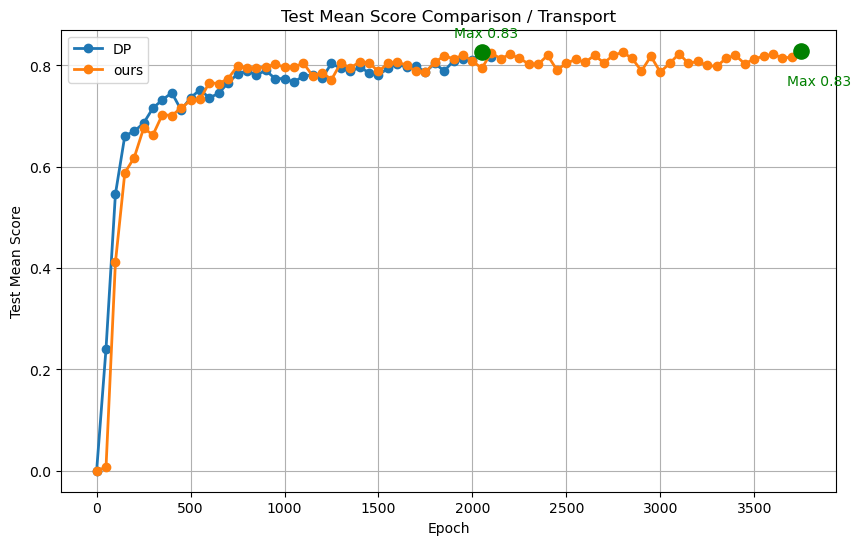

In [ ]:
file_name_1 = f"data/outputs/2026.03.12/17.44.35_train_diffusion_unet_lowdim_pusht_lowdim/eval_output/eval_log_2026.03.12_23.44.56.json"
file_name_2 = f"data/outputs/2026.03.12/19.02.31_train_prob_diffusion_unet_lowdim_pusht_lowdim/eval_output/eval_log_2026.03.13_11.48.44.json"
#data = load_data(file_name)
data1 = refine (file_name_1)
data2 = refine (file_name_2)

## **Plot success rate**

In [ ]:
plt.figure(figsize=(10,6))
plot_test_score_over_epochs(data1, label="DP", xytext_max = (-20,10), xytext_min=(-30,-20))
plot_test_score_over_epochs(data2, label="ours", xytext_max = (-10,-25), xytext_min=(10,-10))

plt.xlabel("Epoch")
plt.ylabel("Test Mean Score")
plt.title("Test Mean Score Comparison / Transport")
plt.grid(True)
plt.legend()
plt.savefig("test_mean_score_comparison_transport.png")

plt.show()

## **Plot noise prediction error and lower bound of NLL**

In [ ]:
plt.figure(figsize=(10,8))

plot_losses_over_epochs(data1, label="DP", xytext_noise=(-30,10), xytext_nll=(-30,10))
plot_losses_over_epochs(data2, label="Ours", xytext_noise=(10,-20), xytext_nll=(10,-20))

plt.subplot(2,1,1)
plt.ylabel("Noise Prediction Loss")
plt.title("Noise Prediction Loss Comparison")
plt.grid(True)
plt.legend()

plt.subplot(2,1,2)
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.title("NLL Comparison")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("loss_comparison_transport.png")